### Libraries

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from pathlib import Path
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
from xgboost import XGBClassifier

### Load Data

In [2]:
base_dir = Path("..")
models_dir = base_dir / "transformed_data" / "combined_station_groups_1km" / "models"

with open(models_dir / "next_month_catboost_grouped_bike_1km_metadata.json") as f:
    metadata = json.load(f)

df = pd.read_csv(
    base_dir / "transformed_data" / "combined_station_groups_1km" / 
    "outputs" / "station_group_month_bike_crash_dataset_1km_next_month.csv"
)

print(f"Dataset shape: {df.shape}")

Dataset shape: (2992, 133)


### Model Comparison

In [6]:
#Split data
TARGET_COLUMN = "target_bike_crash_happened_next_month_1km_grouped"
SIBLING_TARGET_COLUMN = "target_bike_crash_count_next_month_1km_grouped"

df["year_month_index"] = df["year"] * 100 + df["month"]
unique_periods = sorted(df["year_month_index"].unique())
train_end = int(len(unique_periods) * 0.6)
validation_end = int(len(unique_periods) * 0.8)

train_df = df[df["year_month_index"].isin(set(unique_periods[:train_end]))].copy()
validation_df = df[df["year_month_index"].isin(set(unique_periods[train_end:validation_end]))].copy()
test_df = df[df["year_month_index"].isin(set(unique_periods[validation_end:]))].copy()

feature_columns = metadata["feature_columns"]
fill_values = metadata["numeric_fill_values"]
categorical_features = set(metadata["categorical_features"])

y_train = train_df[TARGET_COLUMN]
y_test = test_df[TARGET_COLUMN]

print(f"Train: {len(train_df)} | Validation: {len(validation_df)} | Test: {len(test_df)}")
print(f"Positive rate in test: {y_test.mean():.2%}")

#Prepare features
def prepare_X(df):
    X = df[feature_columns].copy()
    for col in X.columns:
        if col in categorical_features:
            X[col] = X[col].fillna("missing").astype(str)
        else:
            X[col] = pd.to_numeric(X[col], errors="coerce").fillna(fill_values.get(col, 0.0))
    return pd.get_dummies(X, columns=list(categorical_features))

def prepare_X_lgbm(df):
    X = df[feature_columns].copy()
    for col in X.columns:
        if col in categorical_features:
            X[col] = X[col].fillna("missing").astype("category")
        else:
            X[col] = pd.to_numeric(X[col], errors="coerce").fillna(fill_values.get(col, 0.0))
    return X

def prepare_X_catboost(df):
    X = df[feature_columns].copy()
    for col in X.columns:
        if col in categorical_features:
            X[col] = X[col].fillna("missing").astype(str)
        else:
            X[col] = pd.to_numeric(X[col], errors="coerce").fillna(fill_values.get(col, 0.0))
    return X

X_train = prepare_X(train_df)
X_test = prepare_X(test_df)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

X_train_lgbm = prepare_X_lgbm(train_df)
X_test_lgbm = prepare_X_lgbm(test_df)

X_train_catboost = prepare_X_catboost(train_df)
X_test_catboost = prepare_X_catboost(test_df)

cat_indices = [list(X_train_catboost.columns).index(col)
               for col in categorical_features
               if col in X_train_catboost.columns]

#Train and evaluate
def find_best_threshold(y_true, y_score):
    best_threshold, best_f1 = 0.5, -1
    for threshold in np.arange(0.05, 0.96, 0.01):
        y_pred = (y_score >= threshold).astype(int)
        score = f1_score(y_true, y_pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_threshold = float(round(threshold, 2))
    return best_threshold

models = {
    "Random Forest": (RandomForestClassifier(n_estimators=200, random_state=42), X_train, X_test),
    "XGBoost":       (XGBClassifier(n_estimators=200, random_state=42, eval_metric="auc"), X_train, X_test),
    "LightGBM":      (lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1), X_train_lgbm, X_test_lgbm),
    "CatBoost":      (CatBoostClassifier(iterations=200, random_seed=42, verbose=False, cat_features=cat_indices), X_train_catboost, X_test_catboost),
}

results = []
for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    y_score = model.predict_proba(X_te)[:, 1]
    threshold = find_best_threshold(y_test, y_score)
    y_pred = (y_score >= threshold).astype(int)
    results.append({
        "Model": name,
        "ROC AUC": round(roc_auc_score(y_test, y_score), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(float((y_pred[y_test==1] == 1).mean()), 4),
        "Precision": round(float((y_test[y_pred==1] == 1).mean()), 4),
        "Threshold": threshold
    })
    print(f"{name} done")

comparison_df = pd.DataFrame(results).set_index("Model")
print(f"\n{comparison_df}")


Train: 820 | Validation: 1067 | Test: 1105
Positive rate in test: 30.14%
Random Forest done
XGBoost done
LightGBM done
CatBoost done

               ROC AUC      F1  Recall  Precision  Threshold
Model                                                       
Random Forest   0.7302  0.5600  0.5676     0.5526       0.47
XGBoost         0.7167  0.5531  0.6486     0.4821       0.29
LightGBM        0.7364  0.5755  0.6637     0.5080       0.06
CatBoost        0.7490  0.5790  0.6547     0.5190       0.35


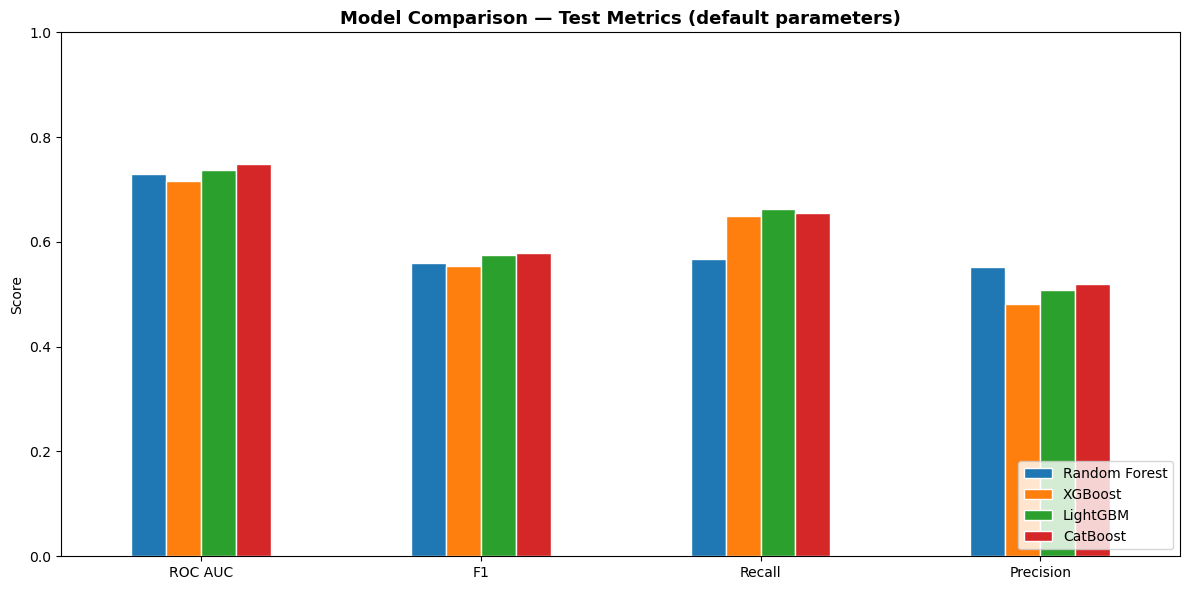

In [8]:
#Plot
comparison_df[["ROC AUC", "F1", "Recall", "Precision"]].T.plot(
    kind="bar", figsize=(12, 6), edgecolor="white"
)
plt.title("Model Comparison — Test Metrics (default parameters)", fontsize=13, fontweight="bold")
plt.xlabel("")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

We decided to go with Catboost

### Model Comparison with 500m

In [16]:
df_500m = pd.read_csv(
    base_dir / "transformed_data" / "combined_station_groups_500m" /
    "outputs" / "station_group_month_bike_crash_dataset_500m_next_month.csv"
)

TARGET_500M = "target_bike_crash_happened_next_month_500m_grouped"
SIBLING_500M = "target_bike_crash_count_next_month_500m_grouped"

df_500m["year_month_index"] = df_500m["year"] * 100 + df_500m["month"]
unique_periods_500m = sorted(df_500m["year_month_index"].unique())
train_end_500m = int(len(unique_periods_500m) * 0.6)
validation_end_500m = int(len(unique_periods_500m) * 0.8)

train_500m = df_500m[df_500m["year_month_index"].isin(set(unique_periods_500m[:train_end_500m]))].copy()
test_500m = df_500m[df_500m["year_month_index"].isin(set(unique_periods_500m[validation_end_500m:]))].copy()

y_train_500m = train_500m[TARGET_500M]
y_test_500m = test_500m[TARGET_500M]

# Use same feature prep but with 500m columns
feature_cols_500m = [c for c in df_500m.columns 
                     if c not in [TARGET_500M, SIBLING_500M, "year_month_index"]]

def prepare_catboost(df, cols):
    X = df[cols].copy()
    cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].fillna("missing").astype(str)
    for col in num_cols:
        X[col] = pd.to_numeric(X[col], errors="coerce").fillna(X[col].median())
    return X, [X.columns.get_loc(c) for c in cat_cols]

X_train_500m, cat_idx_500m = prepare_catboost(train_500m, feature_cols_500m)
X_test_500m, _ = prepare_catboost(test_500m, feature_cols_500m)

model_500m = CatBoostClassifier(iterations=200, random_seed=42, verbose=False, cat_features=cat_idx_500m)
model_500m.fit(X_train_500m, y_train_500m)
y_score_500m = model_500m.predict_proba(X_test_500m)[:, 1]

threshold_500m = find_best_threshold(y_test_500m, y_score_500m)
y_pred_500m = (y_score_500m >= threshold_500m).astype(int)

print("CatBoost 500m results:")
print(f"ROC AUC:   {roc_auc_score(y_test_500m, y_score_500m):.4f}")
print(f"F1:        {f1_score(y_test_500m, y_pred_500m, zero_division=0):.4f}")
print(f"Recall:    {float((y_pred_500m[y_test_500m==1]==1).mean()):.4f}")
print(f"Precision: {float((y_test_500m[y_pred_500m==1]==1).mean()):.4f}")
print(f"Threshold: {threshold_500m:.2f}")
print(f"\nDataset size: {len(df_500m)} rows, positive rate: {y_test_500m.mean():.2%}")

CatBoost 500m results:
ROC AUC:   0.7149
F1:        0.3810
Recall:    0.3784
Precision: 0.3836
Threshold: 0.30

Dataset size: 2992 rows, positive rate: 13.39%


In [15]:
def evaluate(y_true, y_score):
    threshold = find_best_threshold(y_true, y_score)
    y_pred = (y_score >= threshold).astype(int)
    return {
        "ROC AUC": round(roc_auc_score(y_true, y_score), 4),
        "F1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(float((y_pred[y_true==1]==1).mean()), 4),
        "Precision": round(float((y_true[y_pred==1]==1).mean()), 4),
        "Threshold": round(threshold, 2),
        "Positive rate": f"{y_true.mean():.2%}"
    }

y_score_1km = models["CatBoost"][0].predict_proba(X_test_catboost)[:, 1]

radius_comparison = pd.DataFrame([
    {"Radius": "1km", **evaluate(y_test, y_score_1km)},
    {"Radius": "500m", **evaluate(y_test_500m, y_score_500m)},
]).set_index("Radius")

print(radius_comparison)

        ROC AUC     F1  Recall  Precision  Threshold Positive rate
Radius                                                            
1km      0.7490  0.579  0.6547     0.5190       0.35        30.14%
500m     0.7149  0.381  0.3784     0.3836       0.30        13.39%


The model does a lot worst with 500m, also the positive rate of accidents is really low